# Step 3: Regime Labeling + Model Training

**Goal:** classify each 15-minute candle into one of three market regimes:

1. **Low-Vol Trending** — calm market, clear directional move
2. **Ranging / Choppy** — calm market, no clear direction
3. **High-Vol Breakout** — volatility is expanding (risk regime), regardless of direction

There's no ground-truth label for "regime" anywhere — no one hands you this. So we define
it ourselves using rules grounded in the features we already engineered
(`vol_ratio`, `trend_strength`), then train a supervised classifier to learn to
recognize these patterns from the full feature set. This "rule-based labeling →
supervised model" approach is a real technique used when ground truth doesn't exist —
worth explaining exactly like this in interviews.


In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import joblib

pd.set_option('display.max_columns', None)
%matplotlib inline


## Load engineered features

We load the `btcusdt_features` table saved at the end of the previous notebook —
this already has all the rolling volatility, trend, RSI, volume, and ATR features computed.
No need to recompute anything.


In [2]:
DB_PATH = "../data/market_data.db"
SYMBOL = "btcusdt"

conn = sqlite3.connect(DB_PATH)
df = pd.read_sql(f"SELECT * FROM {SYMBOL}_features ORDER BY open_time", conn)
conn.close()

df["datetime"] = pd.to_datetime(df["datetime"])
df = df.set_index("datetime").sort_index()

print(df.shape)
df.tail()


(4952, 22)


,open_time,open,high,low,close,volume,close_time,num_trades,fetched_at,log_return,vol_short,vol_long,ma_fast,ma_slow,ma_cross,trend_strength,rsi,vol_ma,volume_ratio,atr,atr_pct,vol_ratio
datetime,,,,,,,,,,,,,,,,,,,,,,
2026-08-22 05:15:00,1787375700000,77336.61,77549.52,76724.68,77305.15,1123.42720,1787376599999,172838,2026-08-22T05:57:13.276062+00:00,-0.000407,0.005239,0.003193,78330.097500,77966.119583,363.977917,0.004708,41.696987,288.917900,3.888396,477.108571,0.006172,1.640893
2026-08-22 05:30:00,1787376600000,77305.15,77571.29,76920.62,77175.88,522.45245,1787377499999,111057,2026-08-22T05:57:13.276062+00:00,-0.001674,0.005236,0.003188,78218.899167,77961.544583,257.354583,0.003335,35.595196,293.470002,1.780258,500.535000,0.006486,1.642682
2026-08-22 05:45:00,1787377500000,77175.88,77508.96,77074.31,77409.14,211.53863,1787378399999,61923,2026-08-22T05:57:13.276062+00:00,0.003018,0.005553,0.003218,78130.494167,77961.887500,168.606667,0.002178,33.269153,294.800265,0.717566,501.172857,0.006474,1.725549
2026-08-22 06:00:00,1787378400000,77380.75,77454.18,77305.26,77305.27,65.05704,1787379299999,15584,2026-08-22T06:03:40.465396+00:00,-0.001343,0.005526,0.003222,78039.749167,77961.455625,78.293542,0.001013,29.554332,290.485332,0.223960,486.953571,0.006299,1.715095
2026-08-22 06:15:00,1787379300000,77181.07,77358.21,77181.07,77286.01,102.67745,1787380199999,14758,2026-08-22T06:20:26.768609+00:00,-0.000249,0.005309,0.003220,77916.249167,77959.330833,-43.081667,-0.000557,29.766458,288.424014,0.355995,482.255714,0.006240,1.648867


## Step 3a: Define regime labeling rule

We use two features we already have:

- **`vol_ratio`** = short-term volatility ÷ long-term volatility.
  - `vol_ratio` > 1 means volatility is *expanding* right now compared to the recent past.
  - `vol_ratio` < 1 means volatility is *contracting* — market is calm relative to its own history.
- **`trend_strength`** = normalized moving-average crossover.
  - Large absolute value = price is clearly trending in one direction.
  - Near zero = price is bouncing around without clear direction.

**Why quantile-based thresholds instead of fixed numbers?**
A fixed threshold like "vol_ratio > 1.5 = high vol" only works for one asset/timeframe.
Quantiles adapt automatically: "top 25% most volatile periods in *this* dataset" is a
threshold that works whether you're looking at BTC, ETH, 15m candles, or 1h candles.
This is more defensible in an interview than a magic number pulled from nowhere.

**Labeling rule:**
```
if vol_ratio is in the top 25% (expanding volatility)  -> High-Vol Breakout
elif |trend_strength| is in the top 40% (clear direction) -> Low-Vol Trending
else                                                    -> Ranging / Choppy
```

We check `vol_ratio` first because a volatility breakout is the dominant regime —
even if price is trending during a volatility spike, the *risk* characteristic
(volatility) is what matters most for a monitoring/alerting use case.


In [3]:
vol_ratio_threshold = df["vol_ratio"].quantile(0.75)
trend_strength_threshold = df["trend_strength"].abs().quantile(0.60)

print(f"vol_ratio 75th percentile (High-Vol cutoff): {vol_ratio_threshold:.3f}")
print(f"|trend_strength| 60th percentile (Trending cutoff): {trend_strength_threshold:.5f}")


def label_regime(row):
    if row["vol_ratio"] >= vol_ratio_threshold:
        return "High-Vol Breakout"
    elif abs(row["trend_strength"]) >= trend_strength_threshold:
        return "Low-Vol Trending"
    else:
        return "Ranging / Choppy"


df["regime"] = df.apply(label_regime, axis=1)
df["regime"].value_counts()


vol_ratio 75th percentile (High-Vol cutoff): 1.160
|trend_strength| 60th percentile (Trending cutoff): 0.00313


regime
Ranging / Choppy     2202
Low-Vol Trending     1512
High-Vol Breakout    1238
Name: count, dtype: int64

## Step 3b: Visualize regimes over time

Before trusting the labels, we eyeball them. Color-coding the price chart by regime is
a strong sanity check — if "High-Vol Breakout" periods don't line up with visually sharp
price swings, the labeling logic needs adjusting.


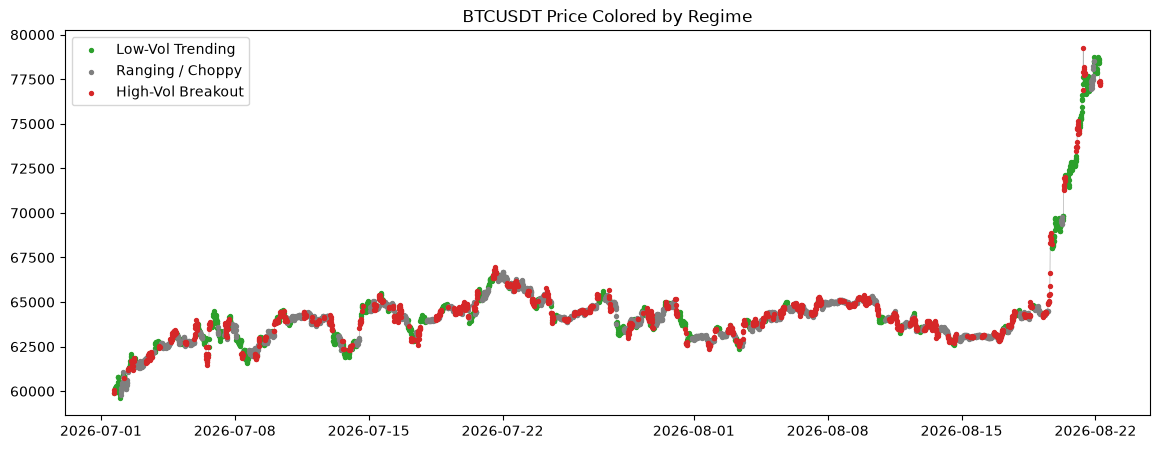

In [4]:
colors = {"Low-Vol Trending": "tab:green", "Ranging / Choppy": "tab:gray", "High-Vol Breakout": "tab:red"}

fig, ax = plt.subplots(figsize=(14, 5))
for regime, color in colors.items():
    subset = df[df["regime"] == regime]
    ax.scatter(subset.index, subset["close"], color=color, label=regime, s=8)

ax.plot(df.index, df["close"], color="black", linewidth=0.5, alpha=0.3, zorder=0)
ax.set_title(f"{SYMBOL.upper()} Price Colored by Regime")
ax.legend()
plt.show()


## Step 3c: Prepare features for modeling — avoiding data leakage

**This is the most important methodological step in the whole notebook, so read closely.**

The regime label was built directly from `vol_ratio` and `trend_strength` (which is
itself derived from `ma_cross`, which is derived from `vol_short`/`vol_long`). If we
include those same columns as model inputs, the model doesn't learn to *detect*
regimes — it just learns to reverse-engineer the threshold rule we hard-coded. This
produces suspiciously perfect accuracy that means nothing. **Any time a model scores
near 100%, treat it as a bug to investigate, not a result to celebrate.**

So we exclude the label-defining columns entirely: `vol_ratio`, `trend_strength`,
`vol_short`, `vol_long`, `ma_cross`.

**We also reframe the problem to be genuinely useful.** If you already know the
*current* regime (you just computed it from live data), you don't need ML to tell you
that — it's already known. The real value is **forecasting the regime a few candles
into the future**, using only features available right now. That's information you
don't already have, and it's what an actual monitoring/alerting system needs: advance
warning before a volatility breakout happens, not confirmation after the fact.

We shift the label forward by `HORIZON` candles (4 candles = 1 hour ahead, on 15m data).

Kept as inputs (genuine leading indicators, not label-defining):
- `log_return` — most recent price movement
- `rsi` — momentum / overbought-oversold state
- `volume_ratio` — current volume anomaly
- `atr`, `atr_pct` — current realized range/volatility (distinct from the vol_ratio used in labeling)


In [5]:
HORIZON = 4  # predict regime 4 candles (1 hour on 15m data) into the future

feature_cols = ["log_return", "rsi", "volume_ratio", "atr", "atr_pct"]

df["future_regime"] = df["regime"].shift(-HORIZON)

model_df = df.dropna(subset=feature_cols + ["future_regime"]).copy()

X = model_df[feature_cols]
y = model_df["future_regime"]

print(f"Predicting regime {HORIZON} candles ahead")
print("Feature columns:", feature_cols)
print(f"Usable rows after shifting: {len(model_df)}")
print("\nClass balance:")
print(y.value_counts(normalize=True).round(3))


Predicting regime 4 candles ahead
Feature columns: ['log_return', 'rsi', 'volume_ratio', 'atr', 'atr_pct']
Usable rows after shifting: 4948

Class balance:
future_regime
Ranging / Choppy     0.445
Low-Vol Trending     0.305
High-Vol Breakout    0.250
Name: proportion, dtype: float64


## Step 3d: Time-based train/test split — NOT random shuffling

**This matters a lot and is a common interview question.** With time-series data, a
random 80/20 shuffle split leaks future information into training (the model could
learn from a candle at 3pm to predict one at 2pm, which is impossible in a live system).

Instead, we split **chronologically**: the model trains only on the earlier portion
of history and is tested on the later, unseen portion — exactly how it would work in
production, where you only ever have the past to predict from.


In [6]:
split_idx = int(len(model_df) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train: {X_train.shape[0]} rows ({X_train.index.min()} to {X_train.index.max()})")
print(f"Test:  {X_test.shape[0]} rows ({X_test.index.min()} to {X_test.index.max()})")


Train: 3958 rows (2026-07-01 16:30:00 to 2026-08-11 21:45:00)
Test:  990 rows (2026-08-11 22:00:00 to 2026-08-22 05:15:00)


## Step 3e: Train the model

We use a **Random Forest classifier** rather than something like an LSTM or deep neural
net, deliberately:

- It's interpretable — we can inspect feature importance and explain *why* it predicts
  what it predicts, which matters a lot in an interview setting
- It handles non-linear relationships between features well (regime detection isn't
  a linear problem)
- It's robust to feature scaling differences (no need to normalize inputs)
- It won't overfit as easily as a deep model on a dataset this size (~1000 rows)

A more complex model would be harder to justify here and easier for an interviewer to
poke holes in ("why didn't you just use logistic regression / why not a simpler model").


In [7]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=10,
    random_state=42,
    class_weight="balanced"  # handles the fact that "High-Vol Breakout" is rarer
)

model.fit(X_train, y_train)
print("Model trained.")


Model trained.


## Step 3f: Evaluate on the held-out test set

We look at precision/recall per class, not just overall accuracy. Overall accuracy
can be misleading with imbalanced classes (e.g., if "Ranging/Choppy" is 50% of the
data, a model that always predicts that class gets 50% accuracy while being useless).


In [8]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))


                   precision    recall  f1-score   support

High-Vol Breakout       0.52      0.47      0.49       266
 Low-Vol Trending       0.69      0.61      0.64       315
 Ranging / Choppy       0.66      0.76      0.71       409

         accuracy                           0.63       990
        macro avg       0.62      0.61      0.62       990
     weighted avg       0.63      0.63      0.63       990



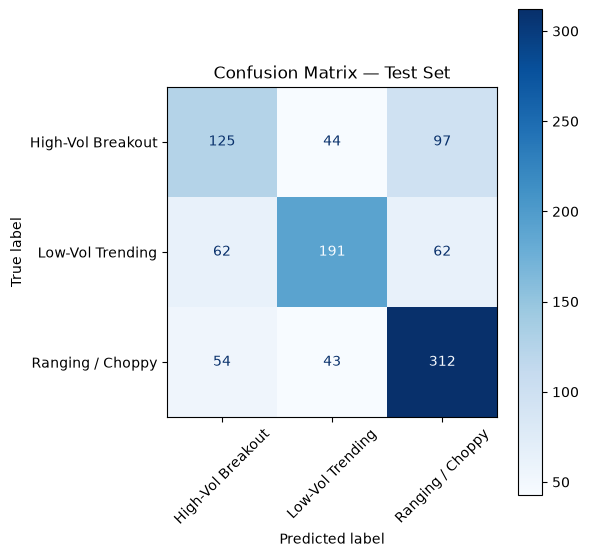

In [9]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.show()


## Step 3g: Feature importance

This tells us which engineered features the model actually relies on — useful both as
a sanity check (do the important features match domain intuition?) and as a talking
point in interviews.


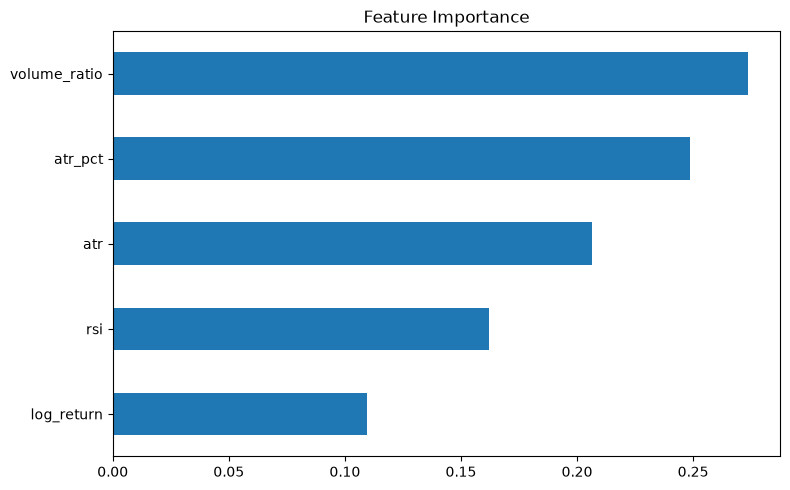

volume_ratio    0.273731
atr_pct         0.248659
atr             0.206248
rsi             0.161901
log_return      0.109461
dtype: float64

In [10]:
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind="barh", ax=ax)
ax.set_title("Feature Importance")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

importances


## Step 3h: Save the trained model

We persist the model to disk so the automation/dashboard step can load it without
retraining every time.


In [11]:
model_path = "../models/regime_classifier.joblib"
joblib.dump({
    "model": model,
    "feature_cols": feature_cols,
    "horizon": HORIZON,
    "vol_ratio_threshold": vol_ratio_threshold,
    "trend_strength_threshold": trend_strength_threshold
}, model_path)

print(f"Model saved to {model_path}")


Model saved to ../models/regime_classifier.joblib


## Step 3i: Horizon comparison — how far ahead can we actually forecast?

We chose 4 candles (1 hour) somewhat arbitrarily earlier. Let's test this properly by
training the same model architecture across several horizons and comparing performance.
This answers a natural question: **does forecasting further ahead get harder (as
expected), and is there a "sweet spot" horizon that's both far enough ahead to be
useful and close enough to still be predictable?**

We reuse the same feature set, same model hyperparameters, and same chronological
split logic for every horizon — the only thing that changes is `HORIZON`. This keeps
the comparison fair (a controlled experiment, not an apples-to-oranges comparison).


In [12]:
from sklearn.metrics import accuracy_score, f1_score

horizons_to_test = [1, 2, 4, 8, 12]  # 15min, 30min, 1hr, 2hr, 3hr ahead (on 15m candles)
results = []

for h in horizons_to_test:
    temp_df = df.copy()
    temp_df["future_regime"] = temp_df["regime"].shift(-h)
    temp_model_df = temp_df.dropna(subset=feature_cols + ["future_regime"]).copy()

    X_h = temp_model_df[feature_cols]
    y_h = temp_model_df["future_regime"]

    split_h = int(len(temp_model_df) * 0.8)
    X_tr, X_te = X_h.iloc[:split_h], X_h.iloc[split_h:]
    y_tr, y_te = y_h.iloc[:split_h], y_h.iloc[split_h:]

    m = RandomForestClassifier(
        n_estimators=200, max_depth=6, min_samples_leaf=10,
        random_state=42, class_weight="balanced"
    )
    m.fit(X_tr, y_tr)
    preds = m.predict(X_te)

    acc = accuracy_score(y_te, preds)
    macro_f1 = f1_score(y_te, preds, average="macro")
    baseline = y_te.value_counts(normalize=True).max()  # majority class baseline

    results.append({
        "horizon_candles": h,
        "horizon_minutes": h * 15,
        "accuracy": round(acc, 3),
        "macro_f1": round(macro_f1, 3),
        "majority_baseline": round(baseline, 3),
        "lift_over_baseline": round(acc - baseline, 3)
    })

results_df = pd.DataFrame(results)
results_df


,horizon_candles,horizon_minutes,accuracy,macro_f1,majority_baseline,lift_over_baseline
0,1,15,0.607,0.576,0.414,0.194
1,2,30,0.635,0.614,0.413,0.222
2,4,60,0.634,0.615,0.413,0.221
3,8,120,0.610,0.593,0.413,0.197
4,12,180,0.583,0.581,0.412,0.171


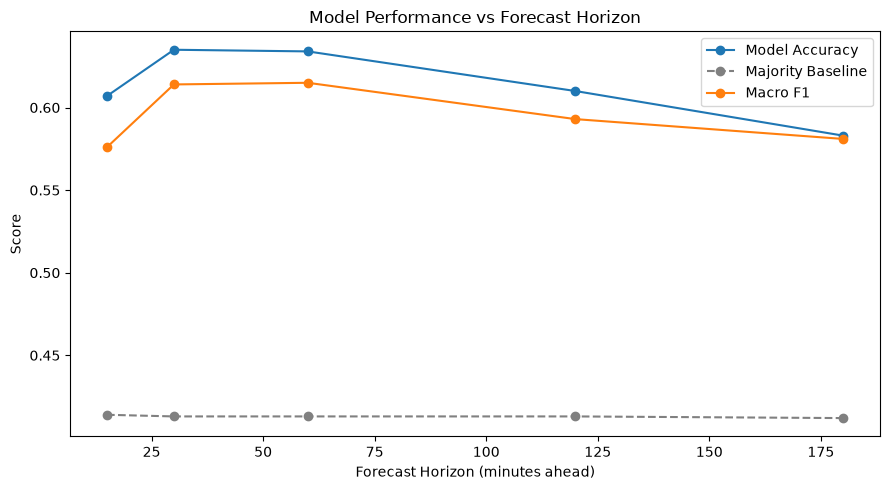

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(results_df["horizon_minutes"], results_df["accuracy"], marker="o", label="Model Accuracy")
ax.plot(results_df["horizon_minutes"], results_df["majority_baseline"], marker="o",
        linestyle="--", color="gray", label="Majority Baseline")
ax.plot(results_df["horizon_minutes"], results_df["macro_f1"], marker="o", label="Macro F1")
ax.set_xlabel("Forecast Horizon (minutes ahead)")
ax.set_ylabel("Score")
ax.set_title("Model Performance vs Forecast Horizon")
ax.legend()
plt.tight_layout()
plt.show()


**How to read this chart:** as the horizon increases, forecasting should generally get
harder (accuracy trending down) since more can change in the market between "now" and
the target time. The gap between the model's accuracy and the gray dashed baseline
line is the real signal — a horizon where the model barely beats baseline isn't adding
much value, even if its raw accuracy looks OK.

Pick the horizon that maximizes **lift over baseline**, not raw accuracy — that's the
one where the model earns its keep. Once you've inspected the table above, update
`HORIZON` in the cell under Step 3c to your chosen value and re-run the notebook from
that point down to retrain and save the final model with the best horizon.


## What we built and why it matters (for interviews)

- We didn't have ground-truth labels, so we **engineered a rule-based labeling scheme**
  grounded in volatility and trend features, using data-driven quantile thresholds
  rather than arbitrary numbers.
- We caught and fixed a **data leakage bug**: our first attempt included the
  label-defining features as model inputs and scored a suspicious ~100% accuracy. We
  diagnosed this correctly (near-perfect accuracy = red flag, not success) and fixed
  it by excluding those columns and reframing the task.
- We reframed the problem from **nowcasting** (predicting the current, already-known
  regime) to **forecasting** (predicting the regime some time ahead using only
  currently available leading indicators) — a harder but genuinely useful task.
- We used a **chronological train/test split** to avoid lookahead bias — a mistake
  many beginners make with time-series data.
- We picked an **interpretable model** (Random Forest) deliberately, over a black-box
  deep learning approach, and can justify that choice.
- We evaluated with **per-class precision/recall**, not just accuracy, because of class
  imbalance (breakouts are rarer than calm periods by design).
- We inspected **feature importance** to confirm the model is learning sensible signal,
  not spurious patterns.

**Next step (Step 4):** wire this into an automated pipeline that pulls new live data,
computes features, predicts the current regime, and logs/alerts on regime shifts.
